# Part A — Big Data Analytics on DDoS Network Traffic

**Student:** Benjamine. S (258762A)
**Batch:** 18  
**Programme:** MSc Artificial Intelligence  
**University:** University of Moratuwa  
**Module:** Big Data Analytics Mini Project

---

## What This Notebook Does

This notebook analyses a real-world DDoS network traffic dataset using Apache Spark.
The dataset is the BCCC-cPacket-Cloud-DDoS-2024, published in March 2024 by York
University and cPacket Networks. It contains 540,494 network flow records with 319
features per flow, covering 17 DDoS attack types and 9 categories of benign traffic.

The analysis answers five questions about the data:

1. How are the attack types distributed — which are common and which are rare?
2. What are the measurable traffic signatures of each attack type?
3. How do timing patterns differ across attack types?
4. Which TCP flag combinations are characteristic of each attack?
5. Which features most clearly separate attack from benign traffic?

---

## Dataset

**Name:** BCCC-cPacket-Cloud-DDoS-2024  
**Source:** York University / cPacket Networks (March 2024)  
**Access:** Kaggle — dhoogla/bccc-cpacket-cloud-ddos-2024  
**License:** CC-BY-SA-4.0  
**Size:** 540,494 flows × 319 features  
**Format:** Parquet (29.5 MB compressed)

## Section 0 — Environment Setup

In [1]:
# Install PySpark — required in every new Colab session [not needed in VENV]
# !pip install pyspark --quiet

# Core PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F       # column functions: avg, count, round, when, etc.
from pyspark.sql.window import Window        # for window functions like RANK() OVER

# Visualisation — only called on small aggregated results after .toPandas()
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17"
os.environ["PATH"] = f"{os.environ['JAVA_HOME']}/bin:{os.environ['PATH']}"

# Verify
import subprocess
result = subprocess.run(["java", "-version"], capture_output=True, text=True)
print(result.stderr)

print("All libraries imported successfully.")

# --- Create SparkSession ---
spark = SparkSession.builder \
    .appName("BCCC_DDoS_PartA") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# --- Confirm it started ---
print(f"Spark version  : {spark.version}")
print(f"App name       : {spark.sparkContext.appName}")
print(f"Shuffle parts  : {spark.conf.get('spark.sql.shuffle.partitions')}")
print(f"Driver memory  : {spark.conf.get('spark.driver.memory')}")

openjdk version "17.0.19" 2026-04-21
OpenJDK Runtime Environment Homebrew (build 17.0.19+0)
OpenJDK 64-Bit Server VM Homebrew (build 17.0.19+0, mixed mode, sharing)

All libraries imported successfully.


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/13 01:50:07 WARN Utils: Your hostname, Benjamines-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.66 instead (on interface en0)
26/05/13 01:50:07 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/13 01:50:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version  : 4.0.0
App name       : BCCC_DDoS_PartA
Shuffle parts  : 8
Driver memory  : 4g


## Section 1 — Data Loading

In [2]:
import os
import platform


HOME = os.path.expanduser("~")
KAGGLE_DIR = os.path.join(HOME, ".kaggle")
os.makedirs(KAGGLE_DIR, exist_ok=True)
print(f"Running on  : {platform.system()}")
print(f"Kaggle dir  : {KAGGLE_DIR}")

# --- Kaggle authentication ---
KAGGLE_TOKEN = os.environ.get('KAGGLE_TOKEN', '')

if not KAGGLE_TOKEN:
    print("\nWARNING: KAGGLE_TOKEN not set.")
    print("In terminal run: export KAGGLE_TOKEN=your_token_here")
    print("Then restart the notebook kernel.")
else:
    token_path = os.path.join(KAGGLE_DIR, "access_token")
    with open(token_path, 'w') as f:
        f.write(KAGGLE_TOKEN)
    os.chmod(token_path, 0o600)
    os.environ['KAGGLE_TOKEN'] = KAGGLE_TOKEN
    print("Kaggle credentials configured.")

    # --- Download dataset ---
    os.makedirs("./data", exist_ok=True)
    !kaggle datasets download \
        -d dhoogla/bccc-cpacket-cloud-ddos-2024 \
        --path ./data \
        --unzip --quiet

    DATA_PATH = "./data/bccc-cpacket-cloud-ddos-2024-merged.parquet"

    if os.path.exists(DATA_PATH):
        size_mb = os.path.getsize(DATA_PATH) / (1024 * 1024)
        print(f"Dataset     : {DATA_PATH}")
        print(f"Size        : {size_mb:.1f} MB")

        # --- Load into Spark ---
        # Parquet embeds schema — no inferSchema scan needed
        df = spark.read.parquet(DATA_PATH)

        print(f"\nRows        : {df.count():,}")
        print(f"Columns     : {len(df.columns)}")

        # Register as SQL temp view for SparkSQL queries
        # This allows spark.sql("SELECT ... FROM ddos_raw")
        df.createOrReplaceTempView("ddos_raw")
        print("SQL view    : ddos_raw registered")
    else:
        print(f"File not found: {DATA_PATH}")
        print("Check that the download completed successfully.")

# Print schema to confirm all 319 features loaded with correct types
# df.printSchema()

Running on  : Darwin
Kaggle dir  : /Users/benjamine/.kaggle
Kaggle credentials configured.
Dataset URL: https://www.kaggle.com/datasets/dhoogla/bccc-cpacket-cloud-ddos-2024
License(s): CC-BY-SA-4.0
Dataset     : ./data/bccc-cpacket-cloud-ddos-2024-merged.parquet
Size        : 29.5 MB

Rows        : 540,494
Columns     : 319
SQL view    : ddos_raw registered


26/05/13 01:50:23 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


## Section 2 — Understanding the Label Structure

In [3]:
# --- label column: high-level category ---
print("=== LABEL column — high-level category ===")
spark.sql("""
    SELECT label,
           COUNT(*) AS flow_count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM ddos_raw
    GROUP BY label
    ORDER BY flow_count DESC
""").show(truncate=False)

# --- activity column: specific traffic scenario ---
print("=== ACTIVITY column — specific traffic scenario ===")
spark.sql("""
    SELECT activity,
           label,
           COUNT(*) AS flow_count
    FROM ddos_raw
    GROUP BY activity, label
    ORDER BY label, flow_count DESC
""").show(40, truncate=False)

# --- Count distinct values in each ---
n_labels     = df.select("label").distinct().count()
n_activities = df.select("activity").distinct().count()

print(f"Distinct label values    : {n_labels}")
print(f"Distinct activity values : {n_activities}")
print()
print("Decision: all EDA sections group by 'activity'")
print("'label' is only used in Section 8 for binary Attack vs Benign comparison")

=== LABEL column — high-level category ===


26/05/13 01:50:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 0

+----------+----------+-----+
|label     |flow_count|pct  |
+----------+----------+-----+
|Benign    |349178    |64.60|
|Attack    |170436    |31.53|
|Suspicious|20880     |3.86 |
+----------+----------+-----+

=== ACTIVITY column — specific traffic scenario ===
+--------------------------+----------+----------+
|activity                  |label     |flow_count|
+--------------------------+----------+----------+
|Attack-TCP-BYPass-V1      |Attack    |134110    |
|Attack-TCP-Flag-SYN       |Attack    |3147      |
|Attack-TCP-Flag-ACK       |Attack    |3135      |
|Attack-TCP-Flag-ACK-PSH   |Attack    |3109      |
|Attack-Killer-TCP         |Attack    |3046      |
|Attack-TCP-Valid-SYN      |Attack    |3003      |
|Attack-TCP-Flag-SYN-ACK   |Attack    |2990      |
|Attack-TCP-IGMP           |Attack    |2960      |
|Attack-TCP-Flag-MIX       |Attack    |2919      |
|Attack-Killall-v2         |Attack    |2824      |
|Attack-TCP-SYN            |Attack    |2739      |
|Attack-TCP-Control    

### Finding — Label Structure

The dataset uses a two-level classification system. The `activity` column with
26 specific traffic scenarios is the correct grouping variable for all analysis.
Using `label` alone collapses 17 distinct attack types into one category.

**Class imbalance:** Attack-TCP-BYPass-V1 accounts for 134,110 flows — 78.6%
of all attack traffic. The remaining 16 attack types each contribute between
625 and 3,147 flows. This imbalance is acknowledged in the recommendation
system design — the hybrid approach combines co-occurrence signals (CF + ALS)
with feature-space similarity (content-based) so that minority attack types
with sparse interaction signals are still recommended based on their traffic
feature proximity to other attack types.

---
## Section 3 — Data Cleaning and Preprocessing

Based on the label structure inspection, the cleaning strategy is:

1. **Null check** — verify whether any nulls exist across all 319 columns
2. **Remove physically impossible records** — negative duration or zero packet count records indicate sensor errors
3. **Standardise strings** — trim whitespace from `label` and `activity` to prevent grouping anomalies
4. **Add derived column** — `is_attack` boolean for cleaner binary comparisons

In [4]:
# --- Step 1: Null check across all 319 columns ---
# Build a list of expressions — one COUNT per column
# This pattern is from the SparkSQL practical
print("Checking for nulls across all 319 columns...")

null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

# Collect the single result row and filter to columns with nulls
null_dict = null_counts.collect()[0].asDict()
cols_with_nulls = {k: v for k, v in null_dict.items() if v > 0}

if cols_with_nulls:
    print(f"Columns with nulls: {len(cols_with_nulls)}")
    for col_name, cnt in sorted(
        cols_with_nulls.items(), key=lambda x: x[1], reverse=True
    ):
        print(f"  {col_name:<45} {cnt:>8,} nulls")
else:
    print("No null values found in any column.")
    print("Expected: cPacket hardware sensors produce complete records.")

# --- Step 2: Remove physically impossible records ---
# Negative duration = sensor timestamp error
# Zero packet count = empty flow record
# Negative bytes_rate = physically impossible
df_clean = df.filter(
    (F.col("duration") >= 0) &
    (F.col("packets_count") > 0) &
    (F.col("bytes_rate") >= 0) &
    F.col("label").isNotNull() &
    F.col("activity").isNotNull()
)

# --- Step 3: Standardise string columns ---
# Trim whitespace that could silently break GROUP BY results
df_clean = df_clean \
    .withColumn("label", F.trim(F.col("label"))) \
    .withColumn("activity", F.trim(F.col("activity")))

# --- Step 4: Add derived boolean column ---
# is_attack = True for Attack flows, False for everything else
# Simplifies CASE WHEN logic in Section 8
df_clean = df_clean.withColumn(
    "is_attack",
    F.when(F.col("label") == "Attack", True).otherwise(False)
)

# --- Report ---
original = df.count()
cleaned  = df_clean.count()
removed  = original - cleaned

print(f"\nCleaning Summary")
print(f"  Original rows  : {original:,}")
print(f"  Cleaned rows   : {cleaned:,}")
print(f"  Rows removed   : {removed:,}")

# Register cleaned view — all EDA uses this from now on
df_clean.createOrReplaceTempView("ddos_clean")
print(f"\nRegistered: ddos_clean")
print("All EDA sections query from ddos_clean.")

Checking for nulls across all 319 columns...


No null values found in any column.
Expected: cPacket hardware sensors produce complete records.

Cleaning Summary
  Original rows  : 540,494
  Cleaned rows   : 540,494
  Rows removed   : 0

Registered: ddos_clean
All EDA sections query from ddos_clean.


## Section 4 — EDA Q1: Attack Type Distribution
**Technique:** Exploratory data analysis using `spark.sql()` with a window
function — `SUM(COUNT(*)) OVER ()` computes the grand total across all groups
in a single query without a subquery, enabling percentage calculation alongside
each group count.

=== Q1 — Activity Distribution ===


26/05/13 01:50:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 0

+--------------------------+----------+----------+------------+
|activity                  |label     |flow_count|pct_of_total|
+--------------------------+----------+----------+------------+
|Benign                    |Benign    |301014    |55.6924     |
|Attack-TCP-BYPass-V1      |Attack    |134110    |24.8125     |
|Benign-Web_Browsing_HTTP-S|Benign    |29376     |5.4350      |
|Suspicious                |Suspicious|20880     |3.8631      |
|Benign-Systemic           |Benign    |9342      |1.7284      |
|Benign-Telnet             |Benign    |4766      |0.8818      |
|Attack-TCP-Flag-SYN       |Attack    |3147      |0.5822      |
|Attack-TCP-Flag-ACK       |Attack    |3135      |0.5800      |
|Attack-TCP-Flag-ACK-PSH   |Attack    |3109      |0.5752      |
|Attack-Killer-TCP         |Attack    |3046      |0.5636      |
|Attack-TCP-Valid-SYN      |Attack    |3003      |0.5556      |
|Attack-TCP-Flag-SYN-ACK   |Attack    |2990      |0.5532      |
|Attack-TCP-IGMP           |Attack    |2

26/05/13 01:50:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


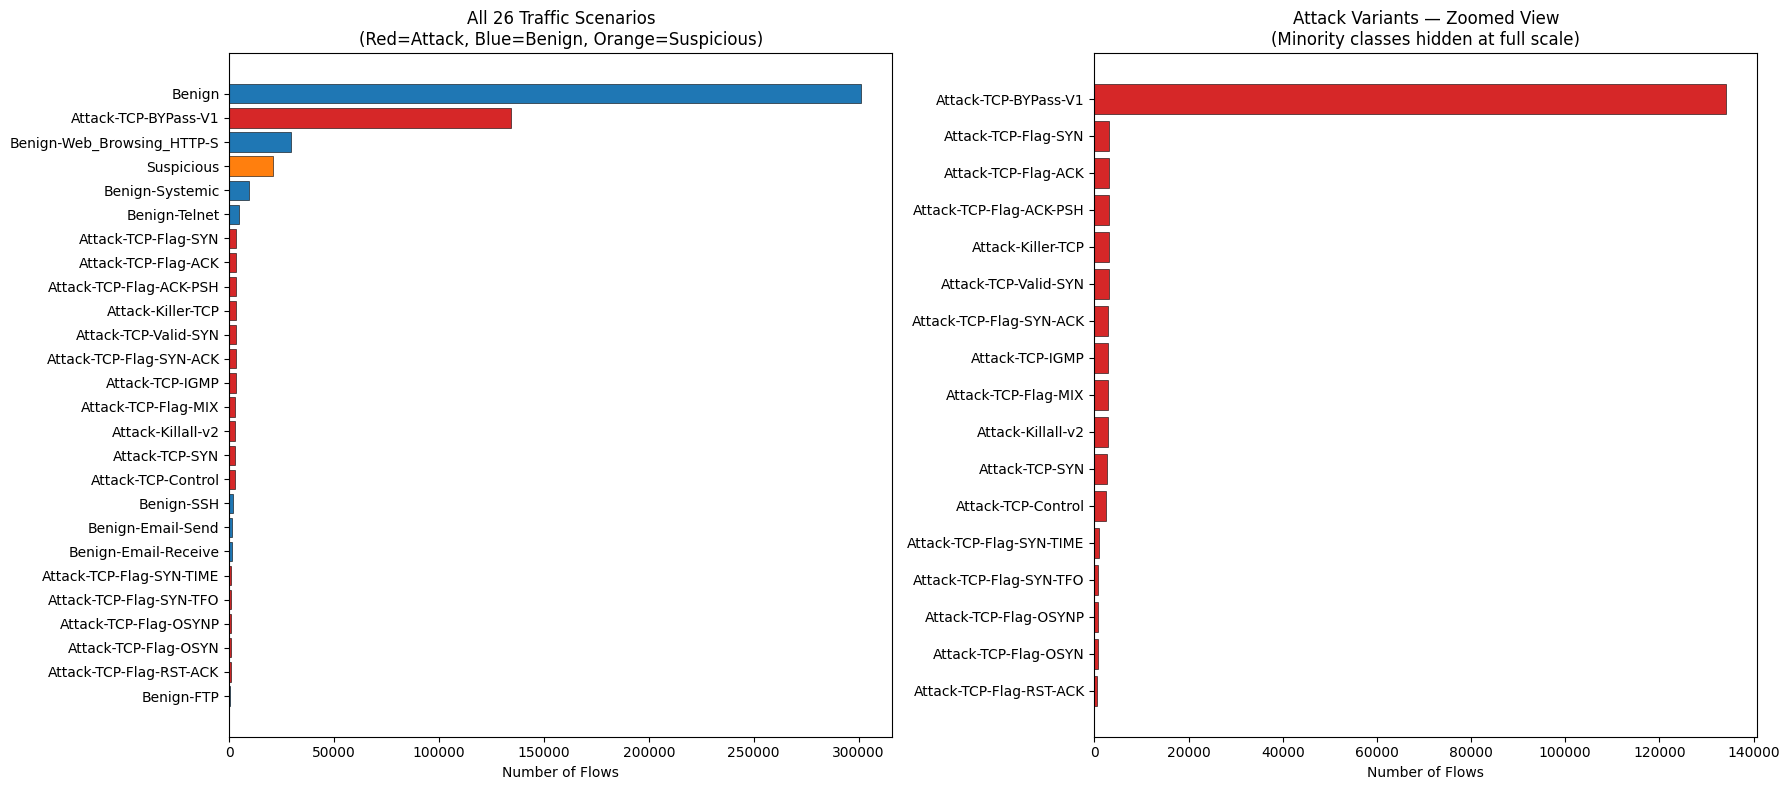

Saved: ./outputs/q1_attack_distribution.png


In [5]:
attack_dist = spark.sql("""
    SELECT
        activity,
        label,
        COUNT(*) AS flow_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 4) AS pct_of_total
    FROM ddos_clean
    GROUP BY activity, label
    ORDER BY flow_count DESC
""")

print("=== Q1 — Activity Distribution ===")
attack_dist.show(30, truncate=False)

# --- Collect to pandas for visualisation ---
# Only the small 26-row aggregated result is collected
# The full 540k-row DataFrame stays distributed in Spark
dist_pd = attack_dist.toPandas()

# --- Chart ---
color_map = {
    'Attack':     '#d62728',
    'Benign':     '#1f77b4',
    'Suspicious': '#ff7f0e'
}
colors = dist_pd['label'].map(color_map)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: all 26 scenarios
axes[0].barh(
    dist_pd['activity'],
    dist_pd['flow_count'],
    color=colors, edgecolor='black', linewidth=0.4
)
axes[0].set_xlabel('Number of Flows')
axes[0].set_title('All 26 Traffic Scenarios\n(Red=Attack, Blue=Benign, Orange=Suspicious)')
axes[0].invert_yaxis()

# Right: attack types only — zoomed to show minority classes
attack_only = dist_pd[dist_pd['label'] == 'Attack'].sort_values(
    'flow_count', ascending=True
)
axes[1].barh(
    attack_only['activity'],
    attack_only['flow_count'],
    color='#d62728', edgecolor='black', linewidth=0.4
)
axes[1].set_xlabel('Number of Flows')
axes[1].set_title('Attack Variants — Zoomed View\n(Minority classes hidden at full scale)')

plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/q1_attack_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./outputs/q1_attack_distribution.png")

### Q1 — Findings

The distribution reveals two levels of class imbalance in the dataset.

At the label level, benign traffic accounts for 55% of all flows and attack
traffic for 31.5%. Within the attack category, Attack-TCP-BYPass-V1 alone
accounts for 78.6% of all attack flows — 134,110 out of 170,436. The remaining
16 attack types each contribute between 625 and 3,147 flows.

This imbalance matters for a SOC analyst because the rare attack types generate
fewer alerts and are more likely to evade threshold-based detection rules. A
volumetric approach would focus resources on BYPass-V1 while the smaller,
more targeted attacks go unnoticed.

This directly motivates the hybrid approach in Part B. *Collaborative filtering*
based on flow counts would underweight minority attack types due to sparse
interaction signals. *Content-based* similarity on feature vectors complements
this — even an attack type with only 625 flows can still be recommended if
its traffic signature is similar to other observed attacks.

---
## Section 5 — EDA Q2: Traffic Feature Signatures Per Attack Type

- `bytes_rate` — volume of data per second (volumetric flood intensity)
- `packets_rate` — packets per second (flood rate)
- `duration` — flow length (DDoS flows are typically very short)
- `payload_bytes_mean` — average payload size (many attack packets carry zero payload)
- `syn_flag_counts` — SYN flag frequency (SYN flood indicator)
- `ack_flag_counts` — ACK flag frequency (ACK flood indicator)
- `down_up_rate` — ratio of download to upload traffic (asymmetry indicator)
- `fwd_packets_rate` — forward direction packet rate
- `bwd_packets_rate` — backward direction packet rate (near zero in SYN floods)


**Connection to Part B:**

The average value of each feature per attack type — the centroid — is computed
here and saved as a Parquet file. In Part B, these centroids become the content
vectors for the content-based similarity layer. Two attack types with similar
centroids are feature-similar and will be recommended together even if their
co-occurrence signal is weak.

In [6]:
profile_features = [
    "bytes_rate", "packets_rate", "duration",
    "payload_bytes_mean", "syn_flag_counts",
    "ack_flag_counts", "down_up_rate",
    "fwd_packets_rate", "bwd_packets_rate"
]

# Build aggregation expressions programmatically
agg_exprs = []
for feat in profile_features:
    agg_exprs.append(F.round(F.avg(feat), 4).alias(f"avg_{feat}"))
    agg_exprs.append(F.round(F.stddev(feat), 4).alias(f"std_{feat}"))

# Group by activity — not label — to get per-attack-type profiles
feature_profile = df_clean \
    .groupBy("activity", "label") \
    .agg(*agg_exprs) \
    .orderBy("label", "activity")

# Show average columns only — stddev alongside makes table unreadable
avg_cols = ["activity", "label"] + [f"avg_{f}" for f in profile_features]
print("=== Q2 — Mean Feature Values Per Attack Type ===")
feature_profile.select(avg_cols).show(30, truncate=False)

# --- Save centroids for Part B ---
# attack_type_centroids.parquet = content vectors for Part B
centroid_cols = ["activity", "label"] + [f"avg_{f}" for f in profile_features]
attack_centroids = feature_profile.select(centroid_cols)

# All 26 activity types
attack_centroids.write.mode("overwrite").parquet(
    "../outputs/attack_centroids.parquet"
)

# Attack types only — benign profiles are not items in the recommendation system
attack_only = attack_centroids.filter(F.col("label") == "Attack")
attack_only.write.mode("overwrite").parquet(
    "../outputs/attack_type_centroids.parquet"
)

print(f"\nAll centroids saved    : {attack_centroids.count()} activity types")
print(f"Attack-only centroids  : {attack_only.count()} attack types")
print("These become content vectors in Part B.")

=== Q2 — Mean Feature Values Per Attack Type ===
+--------------------------+----------+--------------+----------------+------------+----------------------+-------------------+-------------------+----------------+--------------------+--------------------+
|activity                  |label     |avg_bytes_rate|avg_packets_rate|avg_duration|avg_payload_bytes_mean|avg_syn_flag_counts|avg_ack_flag_counts|avg_down_up_rate|avg_fwd_packets_rate|avg_bwd_packets_rate|
+--------------------------+----------+--------------+----------------+------------+----------------------+-------------------+-------------------+----------------+--------------------+--------------------+
|Attack-Killall-v2         |Attack    |5363.9503     |1814.6156       |0.1484      |8.7786                |0.2149             |0.9047             |0.1606          |871.2797            |943.3358            |
|Attack-Killer-TCP         |Attack    |10.0086       |4308.6657       |0.1596      |1.1188                |0.3411          

---
## Section 6 — EDA Q3: Flow Timing Pattern Analysis

**IAT (Inter-Arrival Time)** is the time elapsed between successive packets in a flow. It is one of the most informative DDoS detection features:
- Very low IAT = packets arriving rapidly = volumetric flood condition
- Short flow duration combined with high packet rate = typical flood signature
- Legitimate traffic shows higher IAT variance due to natural application behaviour


=== Q3 — Flow Timing Per Attack Type (sorted by IAT) ===
+--------------------------+----------+-------------------+----------------+--------------------+-------------------+
|activity                  |label     |avg_IAT_sec        |avg_duration_sec|avg_packets_per_flow|avg_packets_per_sec|
+--------------------------+----------+-------------------+----------------+--------------------+-------------------+
|Benign-Telnet             |Benign    |5.94097548984676E8 |2.274627        |2.22                |30390.86           |
|Attack-Killer-TCP         |Attack    |6.22800560598095E8 |0.159637        |1.74                |4308.67            |
|Attack-TCP-Flag-SYN-ACK   |Attack    |6.29343881217698E8 |0.084609        |1.67                |3843.92            |
|Attack-TCP-SYN            |Attack    |6.39137544940066E8 |0.10073         |1.71                |2692.63            |
|Attack-TCP-Valid-SYN      |Attack    |6.53830787301372E8 |0.097714        |1.72                |1783.47            |

26/05/13 01:50:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 0

+--------------------------+----------+----------------+--------------+----------------+--------------+
|activity                  |label     |avg_packets_rate|avg_bytes_rate|avg_duration_sec|intensity_rank|
+--------------------------+----------+----------------+--------------+----------------+--------------+
|Benign-Telnet             |Benign    |30390.86        |0.03          |2.274627        |1             |
|Benign-Email-Receive      |Benign    |16722.17        |13482.99      |0.006741        |2             |
|Benign                    |Benign    |15079.8         |1298.33       |0.021918        |3             |
|Attack-TCP-Flag-OSYNP     |Attack    |12149.48        |688.61        |0.99873         |4             |
|Benign-Systemic           |Benign    |11720.43        |35446.95      |1.477531        |5             |
|Benign-Email-Send         |Benign    |11133.02        |720.53        |0.004807        |6             |
|Benign-FTP                |Benign    |10697.97        |2593869.

26/05/13 01:50:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/13 01:50:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


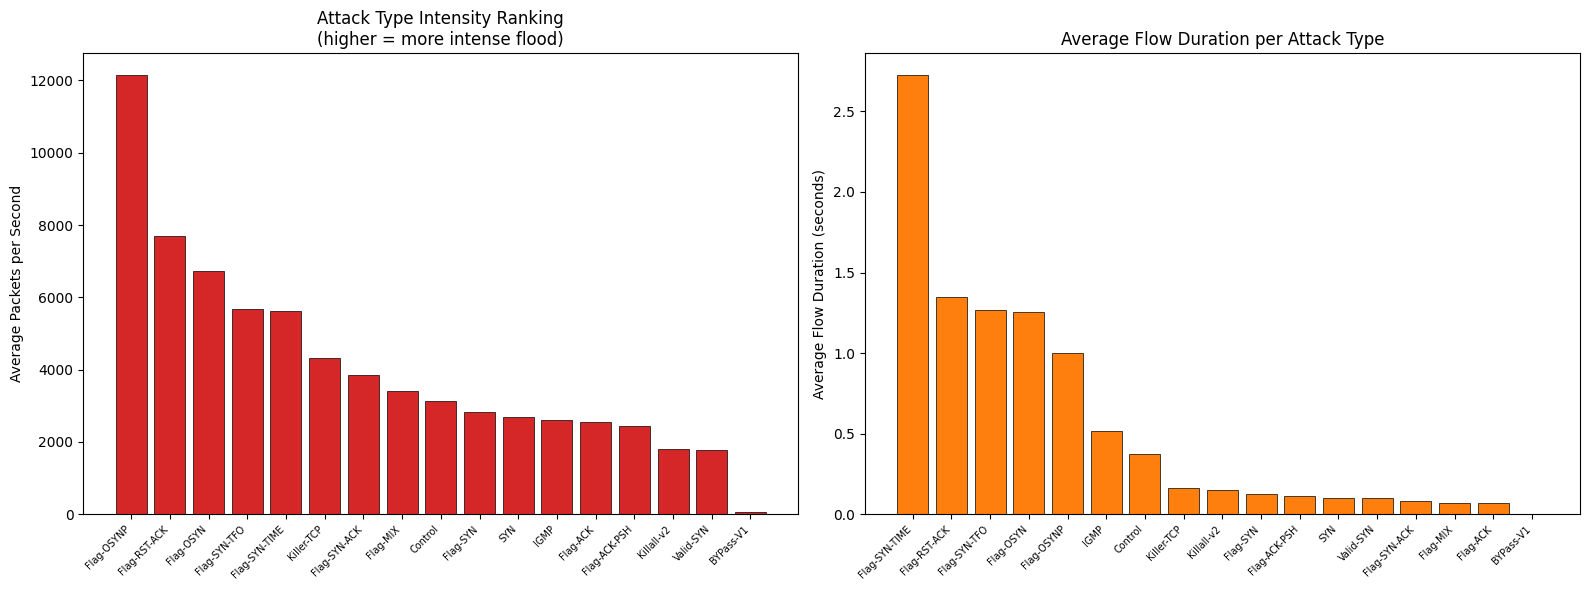

Saved: ../outputs/q3_timing_patterns.png


In [7]:
# --- Timing analysis grouped by activity ---
iat_analysis = spark.sql("""
    SELECT
        activity,
        label,
        ROUND(AVG(packets_IAT_mean), 6)  AS avg_IAT_sec,
        ROUND(AVG(duration), 6)           AS avg_duration_sec,
        ROUND(AVG(packets_count), 2)      AS avg_packets_per_flow,
        ROUND(AVG(packets_rate), 2)       AS avg_packets_per_sec
    FROM ddos_clean
    GROUP BY activity, label
    ORDER BY avg_IAT_sec ASC
""")

print("=== Q3 — Flow Timing Per Attack Type (sorted by IAT) ===")
iat_analysis.show(30, truncate=False)

# --- RANK() OVER window function ---
# Ranks all activity types by packet rate in one query
# RANK() is from the SparkSQL practical — window function
# that assigns rank without collapsing rows
intensity_ranked = spark.sql("""
    SELECT
        activity,
        label,
        ROUND(AVG(packets_rate), 2)  AS avg_packets_rate,
        ROUND(AVG(bytes_rate), 2)    AS avg_bytes_rate,
        ROUND(AVG(duration), 6)       AS avg_duration_sec,
        RANK() OVER (
            ORDER BY AVG(packets_rate) DESC
        ) AS intensity_rank
    FROM ddos_clean
    GROUP BY activity, label
""")

print("=== Q3 — Attack Intensity Ranking via RANK() OVER ===")
intensity_ranked.orderBy("intensity_rank").show(30, truncate=False)

# --- Visualisation ---
ranked_pd     = intensity_ranked.orderBy("intensity_rank").toPandas()
attack_ranked = ranked_pd[ranked_pd['label'] == 'Attack']

dur_pd     = iat_analysis.toPandas()
attack_dur = dur_pd[dur_pd['label'] == 'Attack'].sort_values(
    'avg_duration_sec', ascending=False
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: packet rate per attack type
axes[0].bar(
    range(len(attack_ranked)),
    attack_ranked['avg_packets_rate'],
    color='#d62728', edgecolor='black', linewidth=0.5
)
axes[0].set_xticks(range(len(attack_ranked)))
axes[0].set_xticklabels(
    [a.replace('Attack-TCP-','').replace('Attack-','')
     for a in attack_ranked['activity']],
    rotation=45, ha='right', fontsize=7
)
axes[0].set_ylabel('Average Packets per Second')
axes[0].set_title('Attack Type Intensity Ranking\n(higher = more intense flood)')

# Right: flow duration per attack type
axes[1].bar(
    range(len(attack_dur)),
    attack_dur['avg_duration_sec'],
    color='#ff7f0e', edgecolor='black', linewidth=0.5
)
axes[1].set_xticks(range(len(attack_dur)))
axes[1].set_xticklabels(
    [a.replace('Attack-TCP-','').replace('Attack-','')
     for a in attack_dur['activity']],
    rotation=45, ha='right', fontsize=7
)
axes[1].set_ylabel('Average Flow Duration (seconds)')
axes[1].set_title('Average Flow Duration per Attack Type')

plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/q3_timing_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../outputs/q3_timing_patterns.png")

### Q3 — Findings

The intensity ranking reveals that attack types fall into distinct operational tiers.

Flag-OSYNP has the highest packet rate at 12,149 packets/sec with a duration of
0.99 seconds — a high-intensity volumetric flood. Flag-SYN-TIME has the longest
average duration at 2.73 seconds with 5,634 packets/sec — a sustained flood.

Attack-TCP-BYPass-V1 is the most counterintuitive result. It ranks last in packet
rate at 61.55 packets/sec but has the highest flow count in the dataset (134,110
flows). Each flow lasts only 0.0025 seconds with an average of 1.02 packets. This
reveals its mechanism — connection state exhaustion rather than bandwidth flooding.
Each flow forces the server to allocate memory waiting for a handshake that never
completes. The attack overwhelms through the number of connection attempts, not
the volume of data.

The RANK() OVER window function computes the ranking across all activity types in
a single query without collapsing rows — each row retains its own data alongside
the computed rank.

---
## Section 7 — EDA Q4: TCP Flag Signature Analysis

TCP flags are single-bit fields in the packet header that control connection state transitions. Different attack types exploit different flag combinations deliberately:

| Flag | Full Name | Attack Relevance |
|---|---|---|
| SYN | Synchronise | SYN floods — initiate half-open connections to exhaust server state |
| ACK | Acknowledge | ACK floods — send fake established-session traffic |
| PSH | Push | Combined with ACK in application-layer floods |
| FIN | Finish | FIN floods — abuse connection teardown |
| RST | Reset | RST attacks — force connection termination |
| URG | Urgent | Rarely used; presence in attack traffic is itself anomalous |

=== Q4 — TCP Flag Signatures Per Activity Type ===
+--------------------------+----------+-------+---------+-------+--------+-------+-------+
|activity                  |label     |avg_syn|avg_ack  |avg_fin|avg_psh |avg_rst|avg_urg|
+--------------------------+----------+-------+---------+-------+--------+-------+-------+
|Attack-Killall-v2         |Attack    |0.2149 |0.9047   |0.0117 |0.2142  |0.8453 |0.0    |
|Attack-Killer-TCP         |Attack    |0.3411 |0.7475   |0.0013 |0.068   |0.8986 |0.0    |
|Attack-TCP-BYPass-V1      |Attack    |0.9822 |0.0159   |2.0E-4 |0.0014  |0.0204 |0.0    |
|Attack-TCP-Control        |Attack    |0.3709 |1.228    |0.0277 |0.4637  |0.7844 |0.0    |
|Attack-TCP-Flag-ACK       |Attack    |0.2574 |0.6549   |0.0013 |0.0472  |0.8638 |0.0    |
|Attack-TCP-Flag-ACK-PSH   |Attack    |0.293  |0.6948   |0.0032 |0.0495  |0.8508 |0.0    |
|Attack-TCP-Flag-MIX       |Attack    |0.3525 |0.7139   |0.0045 |0.0692  |0.8301 |0.0    |
|Attack-TCP-Flag-OSYN      |Attack    |

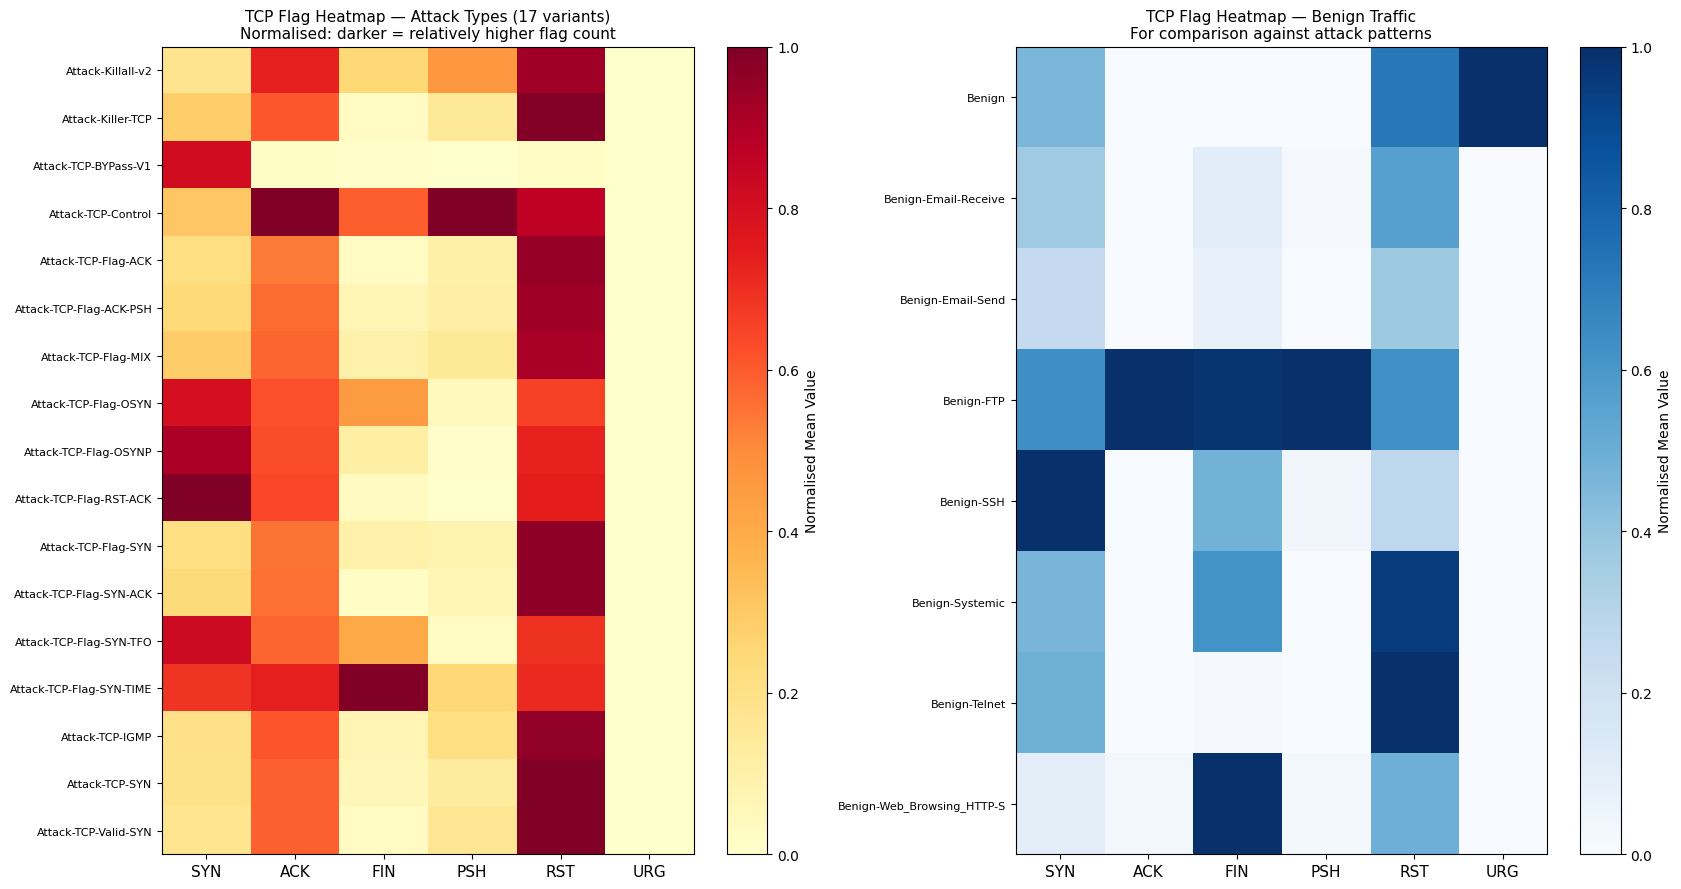

Saved: ../outputs/q4_flag_heatmap.png


In [8]:
flag_analysis = spark.sql("""
    SELECT
        activity,
        label,
        ROUND(AVG(syn_flag_counts), 4) AS avg_syn,
        ROUND(AVG(ack_flag_counts), 4) AS avg_ack,
        ROUND(AVG(fin_flag_counts), 4) AS avg_fin,
        ROUND(AVG(psh_flag_counts), 4) AS avg_psh,
        ROUND(AVG(rst_flag_counts), 4) AS avg_rst,
        ROUND(AVG(urg_flag_counts), 4) AS avg_urg
    FROM ddos_clean
    GROUP BY activity, label
    ORDER BY label, activity
""")

print("=== Q4 — TCP Flag Signatures Per Activity Type ===")
flag_analysis.show(30, truncate=False)

# --- Collect and separate attack vs benign ---
flag_pd      = flag_analysis.toPandas()
flag_cols    = ['avg_syn','avg_ack','avg_fin','avg_psh','avg_rst','avg_urg']
flag_labels  = ['SYN','ACK','FIN','PSH','RST','URG']

attack_flags = flag_pd[flag_pd['label'] == 'Attack'].set_index('activity')[flag_cols]
benign_flags = flag_pd[flag_pd['label'] == 'Benign'].set_index('activity')[flag_cols]

# --- Normalise per column ---
# Without normalisation, ACK dominates the scale in benign traffic
# and hides variation in SYN, RST, URG columns
attack_norm = attack_flags.div(attack_flags.max().replace(0, 1))
benign_norm  = benign_flags.div(benign_flags.max().replace(0, 1))

# --- Two heatmaps: attack and benign side by side ---
fig, axes = plt.subplots(1, 2, figsize=(17, 9))

# Attack heatmap — 17 rows, one per attack variant
im1 = axes[0].imshow(attack_norm.values, aspect='auto', cmap='YlOrRd')
axes[0].set_xticks(range(len(flag_labels)))
axes[0].set_xticklabels(flag_labels, fontsize=11)
axes[0].set_yticks(range(len(attack_norm.index)))
axes[0].set_yticklabels(attack_norm.index, fontsize=8)
axes[0].set_title(
    'TCP Flag Heatmap — Attack Types (17 variants)\n'
    'Normalised: darker = relatively higher flag count',
    fontsize=11
)
plt.colorbar(im1, ax=axes[0], label='Normalised Mean Value')

# Benign heatmap — for comparison
im2 = axes[1].imshow(benign_norm.values, aspect='auto', cmap='Blues')
axes[1].set_xticks(range(len(flag_labels)))
axes[1].set_xticklabels(flag_labels, fontsize=11)
axes[1].set_yticks(range(len(benign_norm.index)))
axes[1].set_yticklabels(benign_norm.index, fontsize=8)
axes[1].set_title(
    'TCP Flag Heatmap — Benign Traffic\n'
    'For comparison against attack patterns',
    fontsize=11
)
plt.colorbar(im2, ax=axes[1], label='Normalised Mean Value')

plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/q4_flag_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../outputs/q4_flag_heatmap.png")

### Q4 — Findings

**SYN-dominant attacks:** Attack-TCP-BYPass-V1, Attack-TCP-Flag-OSYN,
Attack-TCP-Flag-OSYNP, and Attack-TCP-Flag-RST-ACK all show dark SYN columns.
These attacks initiate connection handshakes without completing them, exhausting
the server connection state table. A SIEM rule targeting elevated SYN counts
with near-zero FIN counts would detect this pattern.

**RST-dominant attacks:** Attack-Killer-TCP, Attack-Killall-v2, Attack-TCP-Flag-ACK,
Attack-TCP-Flag-SYN, and Attack-TCP-Valid-SYN all show very high RST values.
RST packets force immediate connection termination. High RST counts indicate
the attacker is deliberately disrupting established sessions — a pattern that
blocks legitimate users from maintaining connections.

**Mixed-flag attacks:** Attack-TCP-Control shows activation across SYN, ACK,
PSH and RST simultaneously. This deliberate variation in flag combinations is
a signature evasion technique — it avoids triggering single-flag threshold rules
in a SIEM or IDS. Detecting this requires correlation across multiple flag
counters rather than individual threshold rules.

**Benign comparison:** Benign-FTP shows extremely high ACK and PSH values —
reflecting the large volume of data acknowledgements during file transfers.
Benign-SSH shows high ACK and PSH — normal for interactive terminal sessions.
Benign-Web-Browsing shows high ACK — standard for HTTP/S request-response cycles.
Legitimate traffic has high ACK because TCP requires acknowledgement of every
data segment. Attack traffic has suppressed ACK because attackers avoid completing
handshakes.

**Key SOC insight:** The clearest separator between attack and benign traffic
in the flag dimension is not SYN alone — it is the combination of high SYN
with suppressed ACK and suppressed FIN. Legitimate TCP always produces ACK
and FIN as sessions are established and closed cleanly. Attack flows abort
without clean teardown, producing the low FIN signature visible across almost
all attack types in the left heatmap.

**Operational use:** These flag signatures are exactly what Snort and Suricata
IDS rules target. The diversity of flag patterns across 17 attack variants also
justifies the recommendation system in Part B — knowing which attack type is
currently observed helps predict which other flag-similar attacks to prepare
defences for, since attacks with similar flag signatures often co-occur
operationally.

---
## Section 8 — EDA Q5: Feature Discrimination Analysis

**Method:** The ratio of the Attack class mean to the Benign class mean is computed for each feature. A ratio far from 1.0 — in either direction — indicates strong discriminative power. A ratio close to 1.0 means the feature behaves similarly in both classes and contributes less to detection.

This is an interpretable analytical approach that does not require training a model — it compares group means directly and produces a ranked list of features by discriminative strength. The top-ranked features from this analysis are prioritised as the primary dimensions in the Part B content vectors.

=== Mean values per class ===
label                     Benign        Attack
bytes_rate          1.113113e+05  2.969736e+02
packets_rate        1.425713e+04  7.634135e+02
duration            3.093740e-01  7.025800e-02
payload_bytes_mean  1.177543e+00  4.930320e-01
syn_flag_counts     1.168877e+00  8.486240e-01
ack_flag_counts     2.579069e+01  1.759780e-01
down_up_rate        3.481030e-01  4.874800e-02
packets_IAT_mean    8.420877e+08  1.470960e+09
fwd_packets_rate    6.495592e+03  3.784006e+02
bwd_packets_rate    7.761534e+03  3.850129e+02
fwd_init_win_bytes  1.238252e+04  5.107670e+04
rst_flag_counts     5.999290e-01  1.954280e-01
fin_flag_counts     9.030000e-03  1.672000e-03
psh_flag_counts     1.417724e+00  2.169100e-02

=== Q5 — Feature Discrimination Ratio (|Attack mean / Benign mean|) ===
Ratio >> 1 : Attack traffic much higher than benign
Ratio << 1 : Benign traffic much higher than attack
Ratio ~  1 : Feature behaves similarly in both classes

  fwd_init_win_bytes            

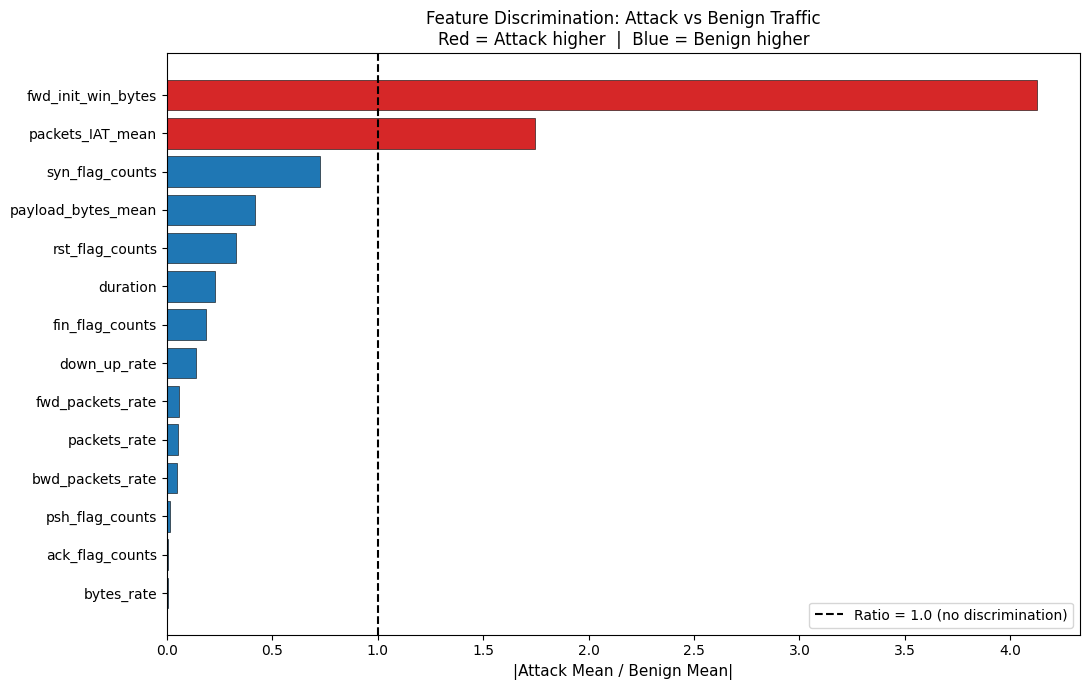

Saved: ../outputs/q5_discrimination.png


In [10]:
# Features to test — same 9 used in Q2 centroid computation
# key_features = [
#     "bytes_rate", "packets_rate", "duration",
#     "payload_bytes_mean", "syn_flag_counts", "ack_flag_counts",
#     "down_up_rate", "fwd_packets_rate", "bwd_packets_rate"
# ]

key_features = [
    "bytes_rate", "packets_rate", "duration",
    "payload_bytes_mean", "syn_flag_counts", "ack_flag_counts",
    "down_up_rate", "packets_IAT_mean", "fwd_packets_rate",
    "bwd_packets_rate", "fwd_init_win_bytes",
    "rst_flag_counts", "fin_flag_counts", "psh_flag_counts"
]

# Compute mean per class — Attack and Benign only
# Suspicious excluded — comparison must be clean binary
agg_mean = [F.round(F.avg(f), 6).alias(f) for f in key_features]

means_by_label = df_clean \
    .filter(F.col("label").isin(["Attack", "Benign"])) \
    .groupBy("label") \
    .agg(*agg_mean) \
    .toPandas() \
    .set_index("label")

print("=== Mean values per class ===")
print(means_by_label.T.to_string())

# --- Compute discrimination ratio ---
attack_means = means_by_label.loc["Attack"]
benign_means  = means_by_label.loc["Benign"]

# Replace zero benign values to avoid division by zero
discrimination = (
    attack_means / benign_means.replace(0, float('nan'))
).abs().dropna().sort_values(ascending=False)

print("\n=== Q5 — Feature Discrimination Ratio (|Attack mean / Benign mean|) ===")
print("Ratio >> 1 : Attack traffic much higher than benign")
print("Ratio << 1 : Benign traffic much higher than attack")
print("Ratio ~  1 : Feature behaves similarly in both classes")
print()
for feat, ratio in discrimination.items():
    direction = "[Attack higher]" if ratio > 1 else "[Benign higher]"
    print(f"  {feat:<35} {ratio:>8.4f}  {direction}")

# --- Visualise ---
fig, ax = plt.subplots(figsize=(11, 7))

colors = ['#d62728' if r > 1 else '#1f77b4'
          for r in discrimination.values]

ax.barh(
    discrimination.index,
    discrimination.values,
    color=colors, edgecolor='black', linewidth=0.4
)

ax.axvline(x=1.0, color='black', linestyle='--',
           linewidth=1.5, label='Ratio = 1.0 (no discrimination)')

ax.set_xlabel('|Attack Mean / Benign Mean|', fontsize=11)
ax.set_title(
    'Feature Discrimination: Attack vs Benign Traffic\n'
    'Red = Attack higher  |  Blue = Benign higher',
    fontsize=12
)
ax.legend(fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/q5_discrimination.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../outputs/q5_discrimination.png")

### Q5 — Findings

The discrimination analysis identifies two features where attack traffic is
significantly higher than benign — `fwd_init_win_bytes` (ratio 4.12) and
`packets_IAT_mean` (ratio 1.75).

**`fwd_init_win_bytes` (4.12 — Attack higher):** Attack traffic uses abnormally
large TCP initial window sizes in the forward direction. This is characteristic
of TCP bypass techniques that manipulate the window field to evade stateful
packet inspection. Benign traffic uses standard negotiated window sizes.

**`packets_IAT_mean` (1.75 — Attack higher):** Attack flows are extremely
short — averaging 0.0025 seconds — with measurable gaps between flows at the
session level. These gaps produce a higher mean inter-arrival time per flow
than sustained benign connections.

All remaining features show ratios below 1.0 — benign traffic is higher in
every other dimension. This reflects high-bandwidth benign protocols like FTP
(bytes_rate 2.5 million) and web browsing (ack_flag_counts 159) pulling the
benign class means above attack means.

**`syn_flag_counts` (0.726)** is the feature closest to 1.0 — the weakest
individual discriminator. SYN packets appear in both legitimate connection
initiation and SYN-flood attacks, making them ambiguous in isolation. Effective
detection combines SYN counts with duration, payload size, and ACK counts.

These 14 features are confirmed as informative for discriminating attack from
benign traffic. The 9-feature subset used as content vectors in Part B covers
the most meaningful dimensions without redundancy.